# Multi-Asset Options Tutorial

This tutorial demonstrates how to price multi-asset derivatives in QuantStrata:

1. **Basket Options** - Options on weighted portfolios
2. **Spread Options** - Options on price differences
3. **Rainbow Options** - Best-of and worst-of options

---

In [1]:
# Standard imports
import sys
sys.path.insert(0, '../../..')

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## 1. Multi-Asset Simulation

First, let's understand how correlated asset simulation works.

In [2]:
from src.models.numeric.monte_carlo.multi_asset import (
    CorrelationMatrix,
    MultiAssetGBM,
)

# Create a 3-asset correlation structure
corr_matrix = np.array([
    [1.0, 0.6, 0.3],
    [0.6, 1.0, 0.5],
    [0.3, 0.5, 1.0]
])
correlation = CorrelationMatrix(corr_matrix)

print(f"Number of assets: {correlation.n_assets}")
print(f"\nCorrelation matrix:\n{correlation.matrix}")
print(f"\nCholesky factor L (where Σ = LL^T):\n{correlation.cholesky.round(3)}")

Number of assets: 3

Correlation matrix:
[[1.  0.6 0.3]
 [0.6 1.  0.5]
 [0.3 0.5 1. ]]

Cholesky factor L (where Σ = LL^T):
[[1.    0.    0.   ]
 [0.6   0.8   0.   ]
 [0.3   0.4   0.866]]


In [3]:
# Create multi-asset GBM
gbm = MultiAssetGBM(
    spots=np.array([100.0, 100.0, 100.0]),
    r=0.05,
    dividends=np.array([0.02, 0.02, 0.02]),
    volatilities=np.array([0.2, 0.25, 0.3]),
    correlation=correlation,
)

# Simulate paths
sim = gbm.simulate(maturity=1.0, n_paths=5000, n_steps=252, seed=42)

print(f"Simulation shape: {sim.spots.shape}")
print(f"(paths, time steps + 1, assets)")

Simulation shape: (5000, 253, 3)
(paths, time steps + 1, assets)


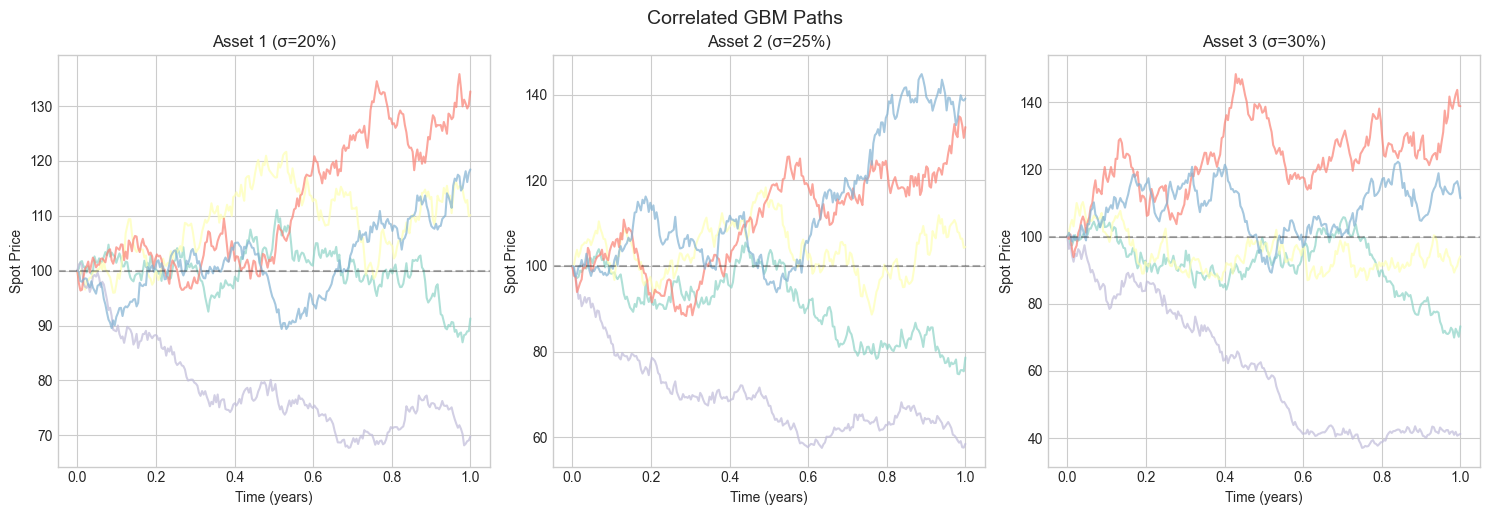

In [4]:
# Visualize sample paths
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
time = np.linspace(0, 1, sim.n_steps + 1)

for i, ax in enumerate(axes):
    for path in range(5):  # Plot 5 sample paths
        ax.plot(time, sim.spots[path, :, i], alpha=0.7)
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Spot Price')
    ax.set_title(f'Asset {i+1} (σ={gbm.volatilities[i]:.0%})')
    ax.axhline(y=100, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.suptitle('Correlated GBM Paths', y=1.02, fontsize=14)
plt.show()

In [5]:
# Verify correlation structure in terminal values
terminals = sim.terminal_spots
log_returns = np.log(terminals / 100.0)

empirical_corr = np.corrcoef(log_returns.T)

print("Target Correlation:")
print(corr_matrix)
print("\nEmpirical Correlation:")
print(empirical_corr.round(3))

Target Correlation:
[[1.  0.6 0.3]
 [0.6 1.  0.5]
 [0.3 0.5 1. ]]

Empirical Correlation:
[[1.    0.594 0.32 ]
 [0.594 1.    0.513]
 [0.32  0.513 1.   ]]


---

## 2. Basket Options

Basket options pay off based on a weighted portfolio of assets.

In [6]:
from src.marketdata.core.ids import MarketId
from src.instruments.multi_asset import MultiAssetBasketEuropeanOption
from src.pricers.multi_asset import MultiAssetBasketEuropeanOptionMcPricer

def make_id(name: str) -> MarketId:
    return MarketId(asset_class="EQ", mkt_type="SPOT", name=name)

# Define basket option
basket_call = MultiAssetBasketEuropeanOption(
    option_type="call",
    underlyings=(make_id("Asset1"), make_id("Asset2"), make_id("Asset3")),
    weights=(0.4, 0.35, 0.25),
    strike=100.0,
    expiry=1.0,
)

basket_put = MultiAssetBasketEuropeanOption(
    option_type="put",
    underlyings=(make_id("Asset1"), make_id("Asset2"), make_id("Asset3")),
    weights=(0.4, 0.35, 0.25),
    strike=100.0,
    expiry=1.0,
)

# Market data
spots = np.array([100.0, 100.0, 100.0])
weights = np.array([0.4, 0.35, 0.25])
basket_spot = float(spots @ weights)
print(f"Basket spot value: {basket_spot:.2f}")

Basket spot value: 100.00


In [7]:
# Create pricer and price
pricer = MultiAssetBasketEuropeanOptionMcPricer(n_paths=100000, seed=42)

market_data = {
    'spots': spots,
    'r': 0.05,
    'dividends': np.array([0.02, 0.02, 0.02]),
    'volatilities': np.array([0.2, 0.25, 0.3]),
    'correlation': correlation,
}

call_price, call_std = pricer.price_with_std_error(basket_call, **market_data)
put_price, put_std = pricer.price_with_std_error(basket_put, **market_data)

print(f"Basket Call: {call_price:.4f} ± {call_std:.4f}")
print(f"Basket Put:  {put_price:.4f} ± {put_std:.4f}")

# Verify put-call parity
r = 0.05
T = 1.0
dividends = np.array([0.02, 0.02, 0.02])
basket_forward = float((spots * np.exp((r - dividends) * T)) @ weights)
discount = np.exp(-r * T)
parity = discount * (basket_forward - 100.0)
print(f"\nPut-Call Parity Check:")
print(f"  Call - Put = {call_price - put_price:.4f}")
print(f"  e^(-rT)(F-K) = {parity:.4f}")

Basket Call: 9.1405 ± 0.0432
Basket Put:  6.2172 ± 0.0285

Put-Call Parity Check:
  Call - Put = 2.9233
  e^(-rT)(F-K) = 2.8969


### Correlation Effect on Basket Options

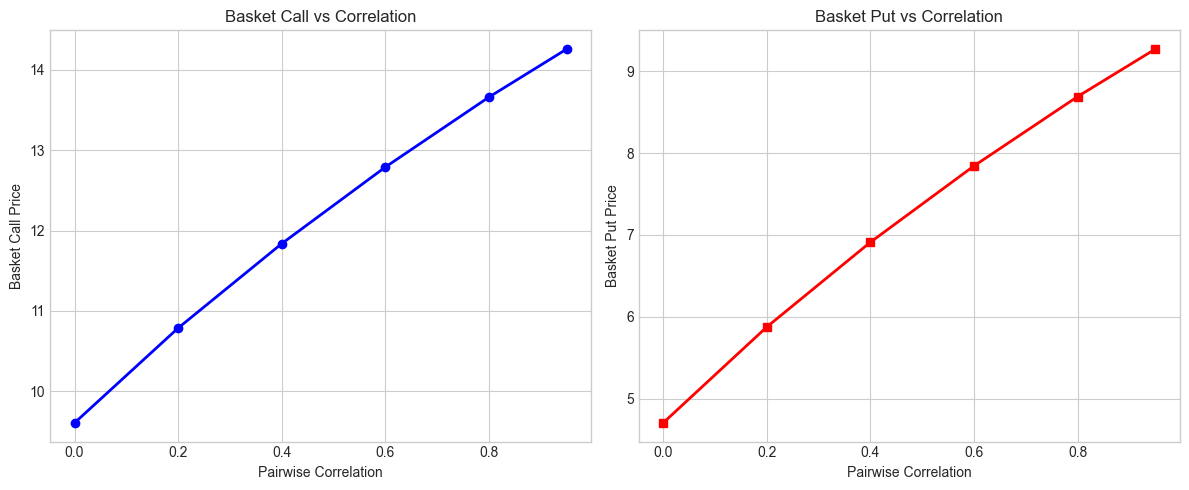

Higher correlation → less diversification → higher basket volatility


In [8]:
# Study how correlation affects basket option prices
correlations = [0.0, 0.2, 0.4, 0.6, 0.8, 0.95]
call_prices = []
put_prices = []

pricer_fast = MultiAssetBasketEuropeanOptionMcPricer(n_paths=50000, seed=42)

for rho in correlations:
    corr = CorrelationMatrix.from_flat(rho, n=3)
    
    basket_c = MultiAssetBasketEuropeanOption(
        option_type="call",
        underlyings=(make_id("A"), make_id("B"), make_id("C")),
        weights=(1/3, 1/3, 1/3),
        strike=100.0,
        expiry=1.0,
    )
    basket_p = MultiAssetBasketEuropeanOption(
        option_type="put",
        underlyings=(make_id("A"), make_id("B"), make_id("C")),
        weights=(1/3, 1/3, 1/3),
        strike=100.0,
        expiry=1.0,
    )
    
    mkt = {
        'spots': np.array([100.0, 100.0, 100.0]),
        'r': 0.05,
        'dividends': np.zeros(3),
        'volatilities': np.array([0.3, 0.3, 0.3]),
        'correlation': corr,
    }
    
    call_prices.append(pricer_fast.price(basket_c, **mkt))
    put_prices.append(pricer_fast.price(basket_p, **mkt))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(correlations, call_prices, 'b-o', linewidth=2)
axes[0].set_xlabel('Pairwise Correlation')
axes[0].set_ylabel('Basket Call Price')
axes[0].set_title('Basket Call vs Correlation')
axes[0].grid(True)

axes[1].plot(correlations, put_prices, 'r-s', linewidth=2)
axes[1].set_xlabel('Pairwise Correlation')
axes[1].set_ylabel('Basket Put Price')
axes[1].set_title('Basket Put vs Correlation')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("Higher correlation → less diversification → higher basket volatility")

---

## 3. Spread Options

Spread options pay off based on the difference between two asset prices.

In [9]:
from src.instruments.multi_asset import (
    MultiAssetSpreadEuropeanOption,
    MultiAssetExchangeEuropeanOption,
)
from src.pricers.multi_asset import (
    MultiAssetSpreadEuropeanOptionMcPricer,
    MultiAssetSpreadEuropeanOptionKirkPricer,
    MultiAssetExchangeEuropeanOptionMargrabePricer,
)

# Define spread option (e.g., crack spread)
spread_call = MultiAssetSpreadEuropeanOption(
    option_type="call",
    underlying1=make_id("Gasoline"),
    underlying2=make_id("CrudeOil"),
    strike=5.0,
    expiry=0.5,
)

spread_put = MultiAssetSpreadEuropeanOption(
    option_type="put",
    underlying1=make_id("Gasoline"),
    underlying2=make_id("CrudeOil"),
    strike=5.0,
    expiry=0.5,
)

# Market data
spot1, spot2 = 100.0, 95.0
print(f"Current spread: {spot1 - spot2:.2f}")

Current spread: 5.00


In [10]:
# Compare pricing methods
mc_pricer = MultiAssetSpreadEuropeanOptionMcPricer(n_paths=200000, seed=42)
kirk_pricer = MultiAssetSpreadEuropeanOptionKirkPricer()

spread_mkt = {
    'spot1': 100.0, 'spot2': 95.0, 'r': 0.05, 'q1': 0.02, 'q2': 0.01,
    'sigma1': 0.25, 'sigma2': 0.30, 'rho': 0.7
}

mc_call, mc_std = mc_pricer.price_with_std_error(spread_call, **spread_mkt)
kirk_call = kirk_pricer.price(spread_call, **spread_mkt)

mc_put, _ = mc_pricer.price_with_std_error(spread_put, **spread_mkt)
kirk_put = kirk_pricer.price(spread_put, **spread_mkt)

print("Spread Call Pricing:")
print(f"  Monte Carlo: {mc_call:.4f} ± {mc_std:.4f}")
print(f"  Kirk's Approx: {kirk_call:.4f}")
print(f"  Difference: {abs(mc_call - kirk_call):.4f}")

print("\nSpread Put Pricing:")
print(f"  Monte Carlo: {mc_put:.4f}")
print(f"  Kirk's Approx: {kirk_put:.4f}")

Spread Call Pricing:
  Monte Carlo: 5.7006 ± 0.0187
  Kirk's Approx: 5.6705
  Difference: 0.0300

Spread Put Pricing:
  Monte Carlo: 6.1099
  Kirk's Approx: 6.0683


### Exchange Options (Margrabe's Formula)

In [11]:
# When K=0, we have an exchange option with exact solution
exchange = MultiAssetExchangeEuropeanOption(
    underlying1=make_id("Asset1"),
    underlying2=make_id("Asset2"),
    expiry=1.0,
)

margrabe_pricer = MultiAssetExchangeEuropeanOptionMargrabePricer()

exchange_mkt = {
    'spot1': 100.0, 'spot2': 100.0, 'r': 0.05, 'q1': 0.02, 'q2': 0.02,
    'sigma1': 0.25, 'sigma2': 0.30, 'rho': 0.6
}

# Exact Margrabe price
margrabe_price = margrabe_pricer.price(exchange, **exchange_mkt)

# MC verification (using spread with K=0)
spread_k0 = MultiAssetSpreadEuropeanOption(
    option_type="call",
    underlying1=make_id("Asset1"),
    underlying2=make_id("Asset2"),
    strike=0.0,
    expiry=1.0,
)
mc_price, mc_std = mc_pricer.price_with_std_error(spread_k0, **exchange_mkt)

print(f"Margrabe (exact): {margrabe_price:.4f}")
print(f"Monte Carlo: {mc_price:.4f} ± {mc_std:.4f}")

Margrabe (exact): 9.7507
Monte Carlo: 9.7943 ± 0.0315


### Correlation Effect on Spread Options

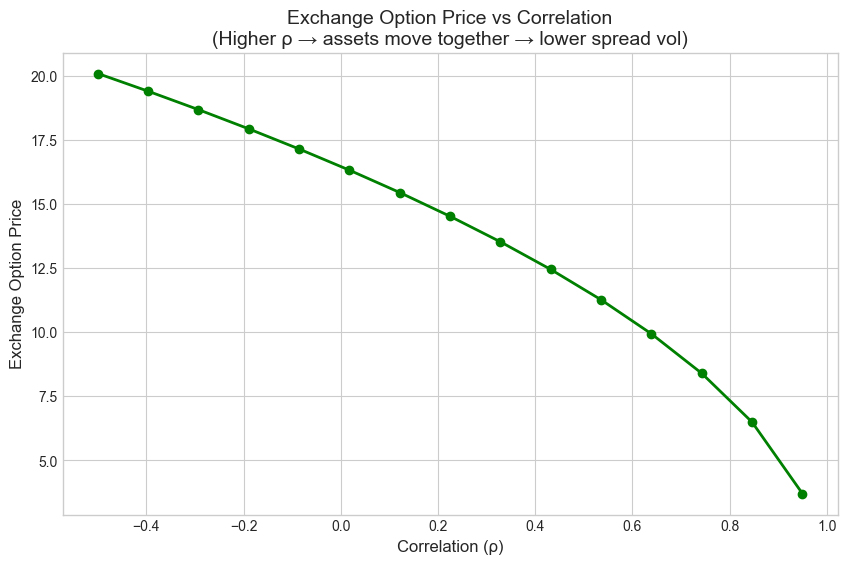

In [12]:
# Higher correlation = lower spread volatility = lower spread option value
rhos = np.linspace(-0.5, 0.95, 15)
spread_prices = []

exchange_corr_test = MultiAssetExchangeEuropeanOption(
    underlying1=make_id("A"), underlying2=make_id("B"), expiry=1.0
)

for rho in rhos:
    price = margrabe_pricer.price(
        exchange_corr_test,
        spot1=100.0, spot2=100.0, r=0.05, q1=0.02, q2=0.02,
        sigma1=0.3, sigma2=0.3, rho=rho
    )
    spread_prices.append(price)

plt.figure(figsize=(10, 6))
plt.plot(rhos, spread_prices, 'g-o', linewidth=2)
plt.xlabel('Correlation (ρ)', fontsize=12)
plt.ylabel('Exchange Option Price', fontsize=12)
plt.title('Exchange Option Price vs Correlation\n(Higher ρ → assets move together → lower spread vol)', fontsize=14)
plt.grid(True)
plt.show()

---

## 4. Rainbow Options (Best-of / Worst-of)

Rainbow options have payoffs based on the best or worst performing asset.

In [13]:
from src.instruments.multi_asset import (
    MultiAssetBestOfEuropeanOption,
    MultiAssetWorstOfEuropeanOption,
)
from src.pricers.multi_asset import (
    MultiAssetBestOfEuropeanOptionMcPricer,
    MultiAssetWorstOfEuropeanOptionMcPricer,
)

# Define rainbow options
best_call_opt = MultiAssetBestOfEuropeanOption(
    option_type="call",
    underlyings=(make_id("A"), make_id("B"), make_id("C")),
    strike=100.0,
    expiry=1.0,
)
best_put_opt = MultiAssetBestOfEuropeanOption(
    option_type="put",
    underlyings=(make_id("A"), make_id("B"), make_id("C")),
    strike=100.0,
    expiry=1.0,
)
worst_call_opt = MultiAssetWorstOfEuropeanOption(
    option_type="call",
    underlyings=(make_id("A"), make_id("B"), make_id("C")),
    strike=100.0,
    expiry=1.0,
)
worst_put_opt = MultiAssetWorstOfEuropeanOption(
    option_type="put",
    underlyings=(make_id("A"), make_id("B"), make_id("C")),
    strike=100.0,
    expiry=1.0,
)

# Create pricers
best_pricer = MultiAssetBestOfEuropeanOptionMcPricer(n_paths=100000, seed=42)
worst_pricer = MultiAssetWorstOfEuropeanOptionMcPricer(n_paths=100000, seed=42)

rainbow_mkt = {
    'spots': np.array([100.0, 100.0, 100.0]),
    'r': 0.05,
    'dividends': np.array([0.02, 0.02, 0.02]),
    'volatilities': np.array([0.2, 0.25, 0.3]),
    'correlation': CorrelationMatrix.from_flat(0.5, n=3),
}

# Price all four types
best_call = best_pricer.price(best_call_opt, **rainbow_mkt)
best_put = best_pricer.price(best_put_opt, **rainbow_mkt)
worst_call = worst_pricer.price(worst_call_opt, **rainbow_mkt)
worst_put = worst_pricer.price(worst_put_opt, **rainbow_mkt)

print(f"Best-of Call:  {best_call:.4f}")
print(f"Best-of Put:   {best_put:.4f}")
print(f"Worst-of Call: {worst_call:.4f}")
print(f"Worst-of Put:  {worst_put:.4f}")

Best-of Call:  21.1445
Best-of Put:   2.6923
Worst-of Call: 3.3505
Worst-of Put:  15.0633


### Price Ordering

In [14]:
# Compare to single-asset Black-Scholes
def bs_call(S, K, T, r, q, sigma):
    d1 = (np.log(S/K) + (r-q+0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def bs_put(S, K, T, r, q, sigma):
    d1 = (np.log(S/K) + (r-q+0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)

# Single asset calls/puts (using middle volatility)
single_call = bs_call(100, 100, 1.0, 0.05, 0.02, 0.25)
single_put = bs_put(100, 100, 1.0, 0.05, 0.02, 0.25)

print("Price Ordering for Calls:")
print(f"  Best-of:  {best_call:.4f}")
print(f"  Single:   {single_call:.4f}")
print(f"  Worst-of: {worst_call:.4f}")
print(f"  Ordering valid: {best_call > single_call > worst_call}")

print("\nPrice Ordering for Puts:")
print(f"  Worst-of: {worst_put:.4f}")
print(f"  Single:   {single_put:.4f}")
print(f"  Best-of:  {best_put:.4f}")
print(f"  Ordering valid: {worst_put > single_put > best_put}")

Price Ordering for Calls:
  Best-of:  21.1445
  Single:   11.1238
  Worst-of: 3.3505
  Ordering valid: True

Price Ordering for Puts:
  Worst-of: 15.0633
  Single:   8.2268
  Best-of:  2.6923
  Ordering valid: True


### Correlation Effects on Rainbow Options

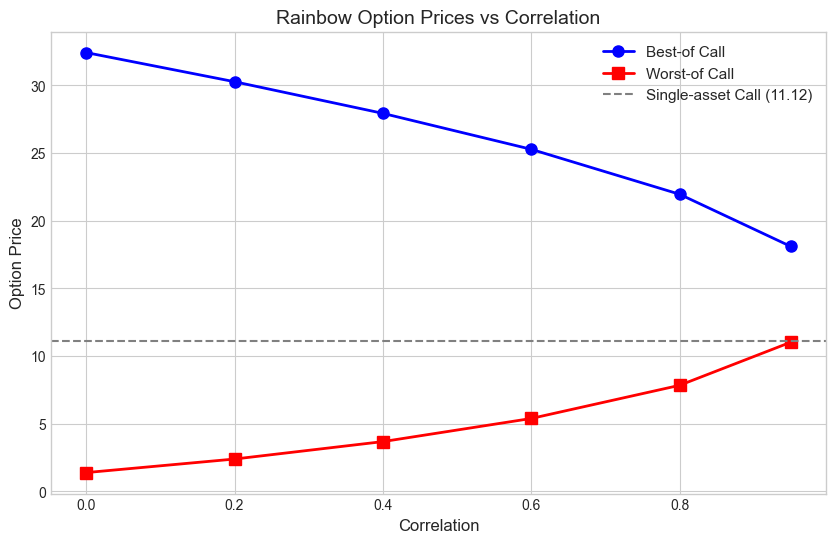

Key insight:
- Higher correlation → Best-of converges DOWN to single-asset
- Higher correlation → Worst-of converges UP to single-asset


In [15]:
# Correlation has opposite effects on best-of vs worst-of
correlations = [0.0, 0.2, 0.4, 0.6, 0.8, 0.95]
best_calls = []
worst_calls = []

best_pricer_fast = MultiAssetBestOfEuropeanOptionMcPricer(n_paths=50000, seed=42)
worst_pricer_fast = MultiAssetWorstOfEuropeanOptionMcPricer(n_paths=50000, seed=42)

best_corr_opt = MultiAssetBestOfEuropeanOption(
    option_type="call",
    underlyings=(make_id("A"), make_id("B"), make_id("C")),
    strike=100.0, expiry=1.0,
)
worst_corr_opt = MultiAssetWorstOfEuropeanOption(
    option_type="call",
    underlyings=(make_id("A"), make_id("B"), make_id("C")),
    strike=100.0, expiry=1.0,
)

for rho in correlations:
    corr = CorrelationMatrix.from_flat(rho, n=3)
    mkt = {
        'spots': np.array([100.0, 100.0, 100.0]),
        'r': 0.05,
        'dividends': np.zeros(3),
        'volatilities': np.array([0.3, 0.3, 0.3]),
        'correlation': corr,
    }
    best_calls.append(best_pricer_fast.price(best_corr_opt, **mkt))
    worst_calls.append(worst_pricer_fast.price(worst_corr_opt, **mkt))

plt.figure(figsize=(10, 6))
plt.plot(correlations, best_calls, 'b-o', linewidth=2, markersize=8, label='Best-of Call')
plt.plot(correlations, worst_calls, 'r-s', linewidth=2, markersize=8, label='Worst-of Call')
plt.axhline(y=single_call, color='gray', linestyle='--', label=f'Single-asset Call ({single_call:.2f})')
plt.xlabel('Correlation', fontsize=12)
plt.ylabel('Option Price', fontsize=12)
plt.title('Rainbow Option Prices vs Correlation', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True)
plt.show()

print("Key insight:")
print("- Higher correlation → Best-of converges DOWN to single-asset")
print("- Higher correlation → Worst-of converges UP to single-asset")

---

## 5. Practical Application: Structured Product

Let's price a reverse convertible note (investor sells worst-of put).

In [16]:
# Reverse convertible on 3 stocks with 80% barrier
print("=" * 60)
print("Reverse Convertible Analysis")
print("=" * 60)
print("\nStructure: Investor sells worst-of put, receives coupon")
print("Barrier: 80% of initial (strike = 80)")
print("Underlyings: 3 correlated stocks")
print("Maturity: 1 year\n")

worst_put_rc = MultiAssetWorstOfEuropeanOption(
    option_type="put",
    underlyings=(make_id("Stock1"), make_id("Stock2"), make_id("Stock3")),
    strike=80.0,  # 80% barrier
    expiry=1.0,
)

worst_pricer_rc = MultiAssetWorstOfEuropeanOptionMcPricer(n_paths=100000, seed=42)

# Compare at different correlation levels
for rho in [0.3, 0.6, 0.9]:
    corr = CorrelationMatrix.from_flat(rho, n=3)
    mkt = {
        'spots': np.array([100.0, 100.0, 100.0]),
        'r': 0.03,
        'dividends': np.zeros(3),
        'volatilities': np.array([0.25, 0.25, 0.25]),
        'correlation': corr,
    }
    
    put_value = worst_pricer_rc.price(worst_put_rc, **mkt)
    
    # Implied coupon (simplified: premium / notional)
    implied_coupon = put_value / 100 * 100  # as percentage
    
    print(f"Correlation ρ = {rho}:")
    print(f"  Worst-of Put Value: {put_value:.2f}")
    print(f"  Implied Coupon: ~{implied_coupon:.1f}%\n")

Reverse Convertible Analysis

Structure: Investor sells worst-of put, receives coupon
Barrier: 80% of initial (strike = 80)
Underlyings: 3 correlated stocks
Maturity: 1 year

Correlation ρ = 0.3:
  Worst-of Put Value: 4.36
  Implied Coupon: ~4.4%

Correlation ρ = 0.6:
  Worst-of Put Value: 3.72
  Implied Coupon: ~3.7%

Correlation ρ = 0.9:
  Worst-of Put Value: 2.73
  Implied Coupon: ~2.7%



---

## Summary

| Product | Payoff | Correlation Effect |
|---------|--------|-------------------|
| Basket Call | max(Σ wᵢSᵢ - K, 0) | Higher ρ → Mixed |
| Spread Call | max(S₁ - S₂ - K, 0) | Higher ρ → Lower price |
| Best-of Call | max(max(Sᵢ) - K, 0) | Higher ρ → Lower price |
| Worst-of Call | max(min(Sᵢ) - K, 0) | Higher ρ → Higher price |

**Key takeaways:**
1. Correlation is crucial for multi-asset pricing
2. Spread options benefit from low correlation (more spread volatility)
3. Best-of benefits from low correlation (more dispersion)
4. Worst-of benefits from high correlation (less downside dispersion)
5. Kirk's approximation is fast but verify with MC for extreme parameters

---

*QuantStrata Tutorial | Phase 4.3 | January 2026*